  Customer ID LastPurchaseDate  PurchaseFrequency  TotalSpending  \
0    AA-10315       2014-06-30                 11       5563.560   
1    AA-10375       2014-12-12                 15       1056.390   
2    AA-10480       2014-04-16                 12       1790.512   
3    AA-10645       2014-11-06                 18       5086.935   
4    AB-10015       2013-11-11                  6        886.156   

   DaysSinceLastPurchase       Risk  
0                    184  High Risk  
1                     19   Low Risk  
2                    259  High Risk  
3                     55   Low Risk  
4                    415  High Risk  

Risk Distribution

Risk
Low Risk       436
High Risk      199
Medium Risk    158
Name: count, dtype: int64


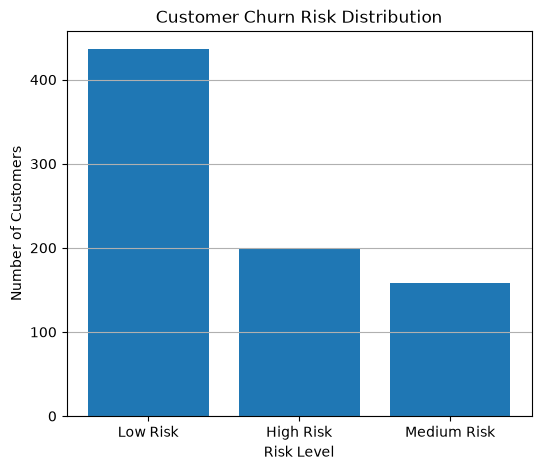


Customer churn analysis completed successfully.


In [ ]:

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("cleaned_dataset.csv")

# ------------------------------------------
# Convert Order Date to Datetime
# ------------------------------------------

df["Order Date"] = pd.to_datetime(df["Order Date"],format="%d-%m-%Y")

# ------------------------------------------
# Find Latest Date in Dataset
# ------------------------------------------

latest_date = df["Order Date"].max()

# ------------------------------------------
# Create Customer-Level Features
# ------------------------------------------

customer_df = df.groupby("Customer ID").agg(
    LastPurchaseDate=("Order Date", "max"),
    PurchaseFrequency=("Order ID", "count"),
    TotalSpending=("Total amount", "sum")
).reset_index()

# ------------------------------------------
# Calculate Days Since Last Purchase
# ------------------------------------------

customer_df["DaysSinceLastPurchase"] = (
    latest_date - customer_df["LastPurchaseDate"]
).dt.days

# ------------------------------------------
# Churn Risk Rules
# ------------------------------------------

def assign_risk(days):

    if days > 180:
        return "High Risk"

    elif days > 90:
        return "Medium Risk"

    else:
        return "Low Risk"

customer_df["Risk"] = customer_df["DaysSinceLastPurchase"].apply(assign_risk)

# ------------------------------------------
# Display Results
# ------------------------------------------

print(customer_df.head())

print("\nRisk Distribution\n")
print(customer_df["Risk"].value_counts())

# ------------------------------------------
# Visualize Risk Distribution
# ------------------------------------------

risk_counts = customer_df["Risk"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.grid(axis="y")
plt.show()

# ------------------------------------------
# Save Output
# ------------------------------------------

customer_df.to_csv(
    "customer_churn.csv",
    index=False
)

print("\nCustomer churn analysis completed successfully.")